In [219]:
import warnings 
warnings.filterwarnings('ignore')

In [220]:
import pandas as pd
import numpy as np
import math

# importing ploting libraries
import matplotlib.pyplot as plt   
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import StandardScaler

In [221]:
# import data set
df = pd.read_csv( 'kc_house_data.csv' )
df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [222]:
# print datatype pf each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
id               21613 non-null int64
date             21613 non-null object
price            21613 non-null float64
bedrooms         21613 non-null int64
bathrooms        21613 non-null float64
sqft_living      21613 non-null int64
sqft_lot         21613 non-null int64
floors           21613 non-null float64
waterfront       21613 non-null int64
view             21613 non-null int64
condition        21613 non-null int64
grade            21613 non-null int64
sqft_above       21613 non-null int64
sqft_basement    21613 non-null int64
yr_built         21613 non-null int64
yr_renovated     21613 non-null int64
zipcode          21613 non-null int64
lat              21613 non-null float64
long             21613 non-null float64
sqft_living15    21613 non-null int64
sqft_lot15       21613 non-null int64
dtypes: float64(5), int64(15), object(1)
memory usage: 3.5+ MB


In [223]:
# check how many missing values
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [224]:
# drop ID column as it is useless for the model
if 'id' in df.columns:
    df.drop(['id'], axis=1, inplace = True)

In [225]:
# get the year from the date column and convert to type int
df['date']=df['date'].astype(str).str[:4]
df['date'] = df['date'].astype('int64')

In [226]:
# check data distribution
df.describe().T

,count,mean,std,min,25%,50%,75%,max
date,21613.0,2014.322954,0.467616,2014.0000,2014.000,2014.0000,2015.000,2.015000e+03
price,21613.0,540088.141767,367127.196483,75000.0000,321950.000,450000.0000,645000.000,7.700000e+06
bedrooms,21613.0,3.370842,0.930062,0.0000,3.000,3.0000,4.000,3.300000e+01
bathrooms,21613.0,2.114757,0.770163,0.0000,1.750,2.2500,2.500,8.000000e+00
sqft_living,21613.0,2079.899736,918.440897,290.0000,1427.000,1910.0000,2550.000,1.354000e+04
sqft_lot,21613.0,15106.967566,41420.511515,520.0000,5040.000,7618.0000,10688.000,1.651359e+06
floors,21613.0,1.494309,0.539989,1.0000,1.000,1.5000,2.000,3.500000e+00
waterfront,21613.0,0.007542,0.086517,0.0000,0.000,0.0000,0.000,1.000000e+00
view,21613.0,0.234303,0.766318,0.0000,0.000,0.0000,0.000,4.000000e+00
condition,21613.0,3.409430,0.650743,1.0000,3.000,3.0000,4.000,5.000000e+00


In [227]:
# check the co-relation between features
df.corr()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
date,1.000000,0.003576,-0.009838,-0.026596,-0.029038,0.005468,-0.022315,-0.004165,0.001364,-0.045589,-0.030387,-0.023823,-0.015687,0.003507,-0.023707,0.001189,-0.029212,0.000270,-0.021734,-0.000085
price,0.003576,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.266369,0.397293,0.036362,0.667434,0.605567,0.323816,0.054012,0.126434,-0.053203,0.307003,0.021626,0.585379,0.082447
bedrooms,-0.009838,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,-0.006582,0.079532,0.028472,0.356967,0.477600,0.303093,0.154178,0.018841,-0.152668,-0.008931,0.129473,0.391638,0.029244
bathrooms,-0.026596,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.029038,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,0.005468,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,-0.022315,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.004165,0.266369,-0.006582,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.001364,0.397293,0.079532,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.045589,0.036362,0.028472,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


In [228]:
# check co-relation of features wrt price
df[df.columns[1:]].corr()['price'][:].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

In [229]:
# select feature columns to check distribution
feature_cols = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','grade','sqft_above','sqft_basement','yr_built','yr_renovated','zipcode']

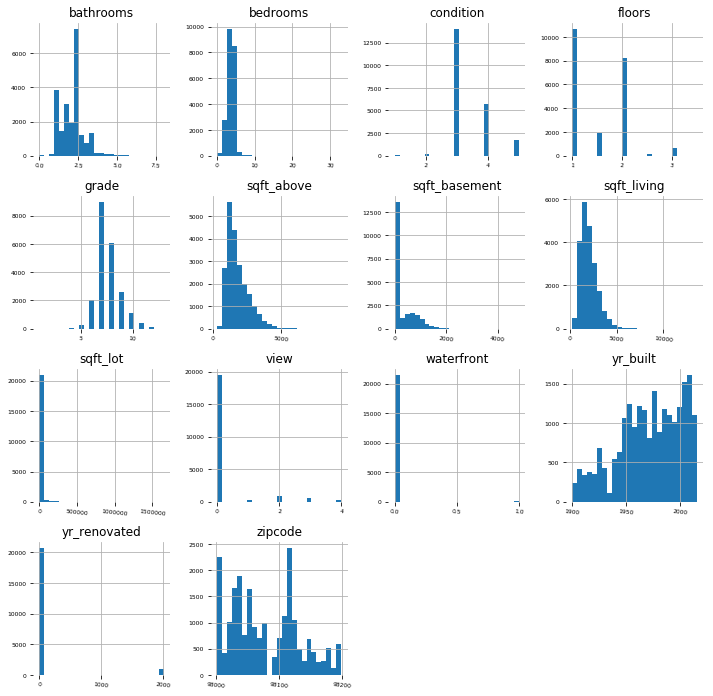

In [230]:
h = df[feature_cols].hist(bins=25,figsize=(12,12),xlabelsize='6',ylabelsize='6',xrot=-6)
sns.despine(left=True, bottom=True)

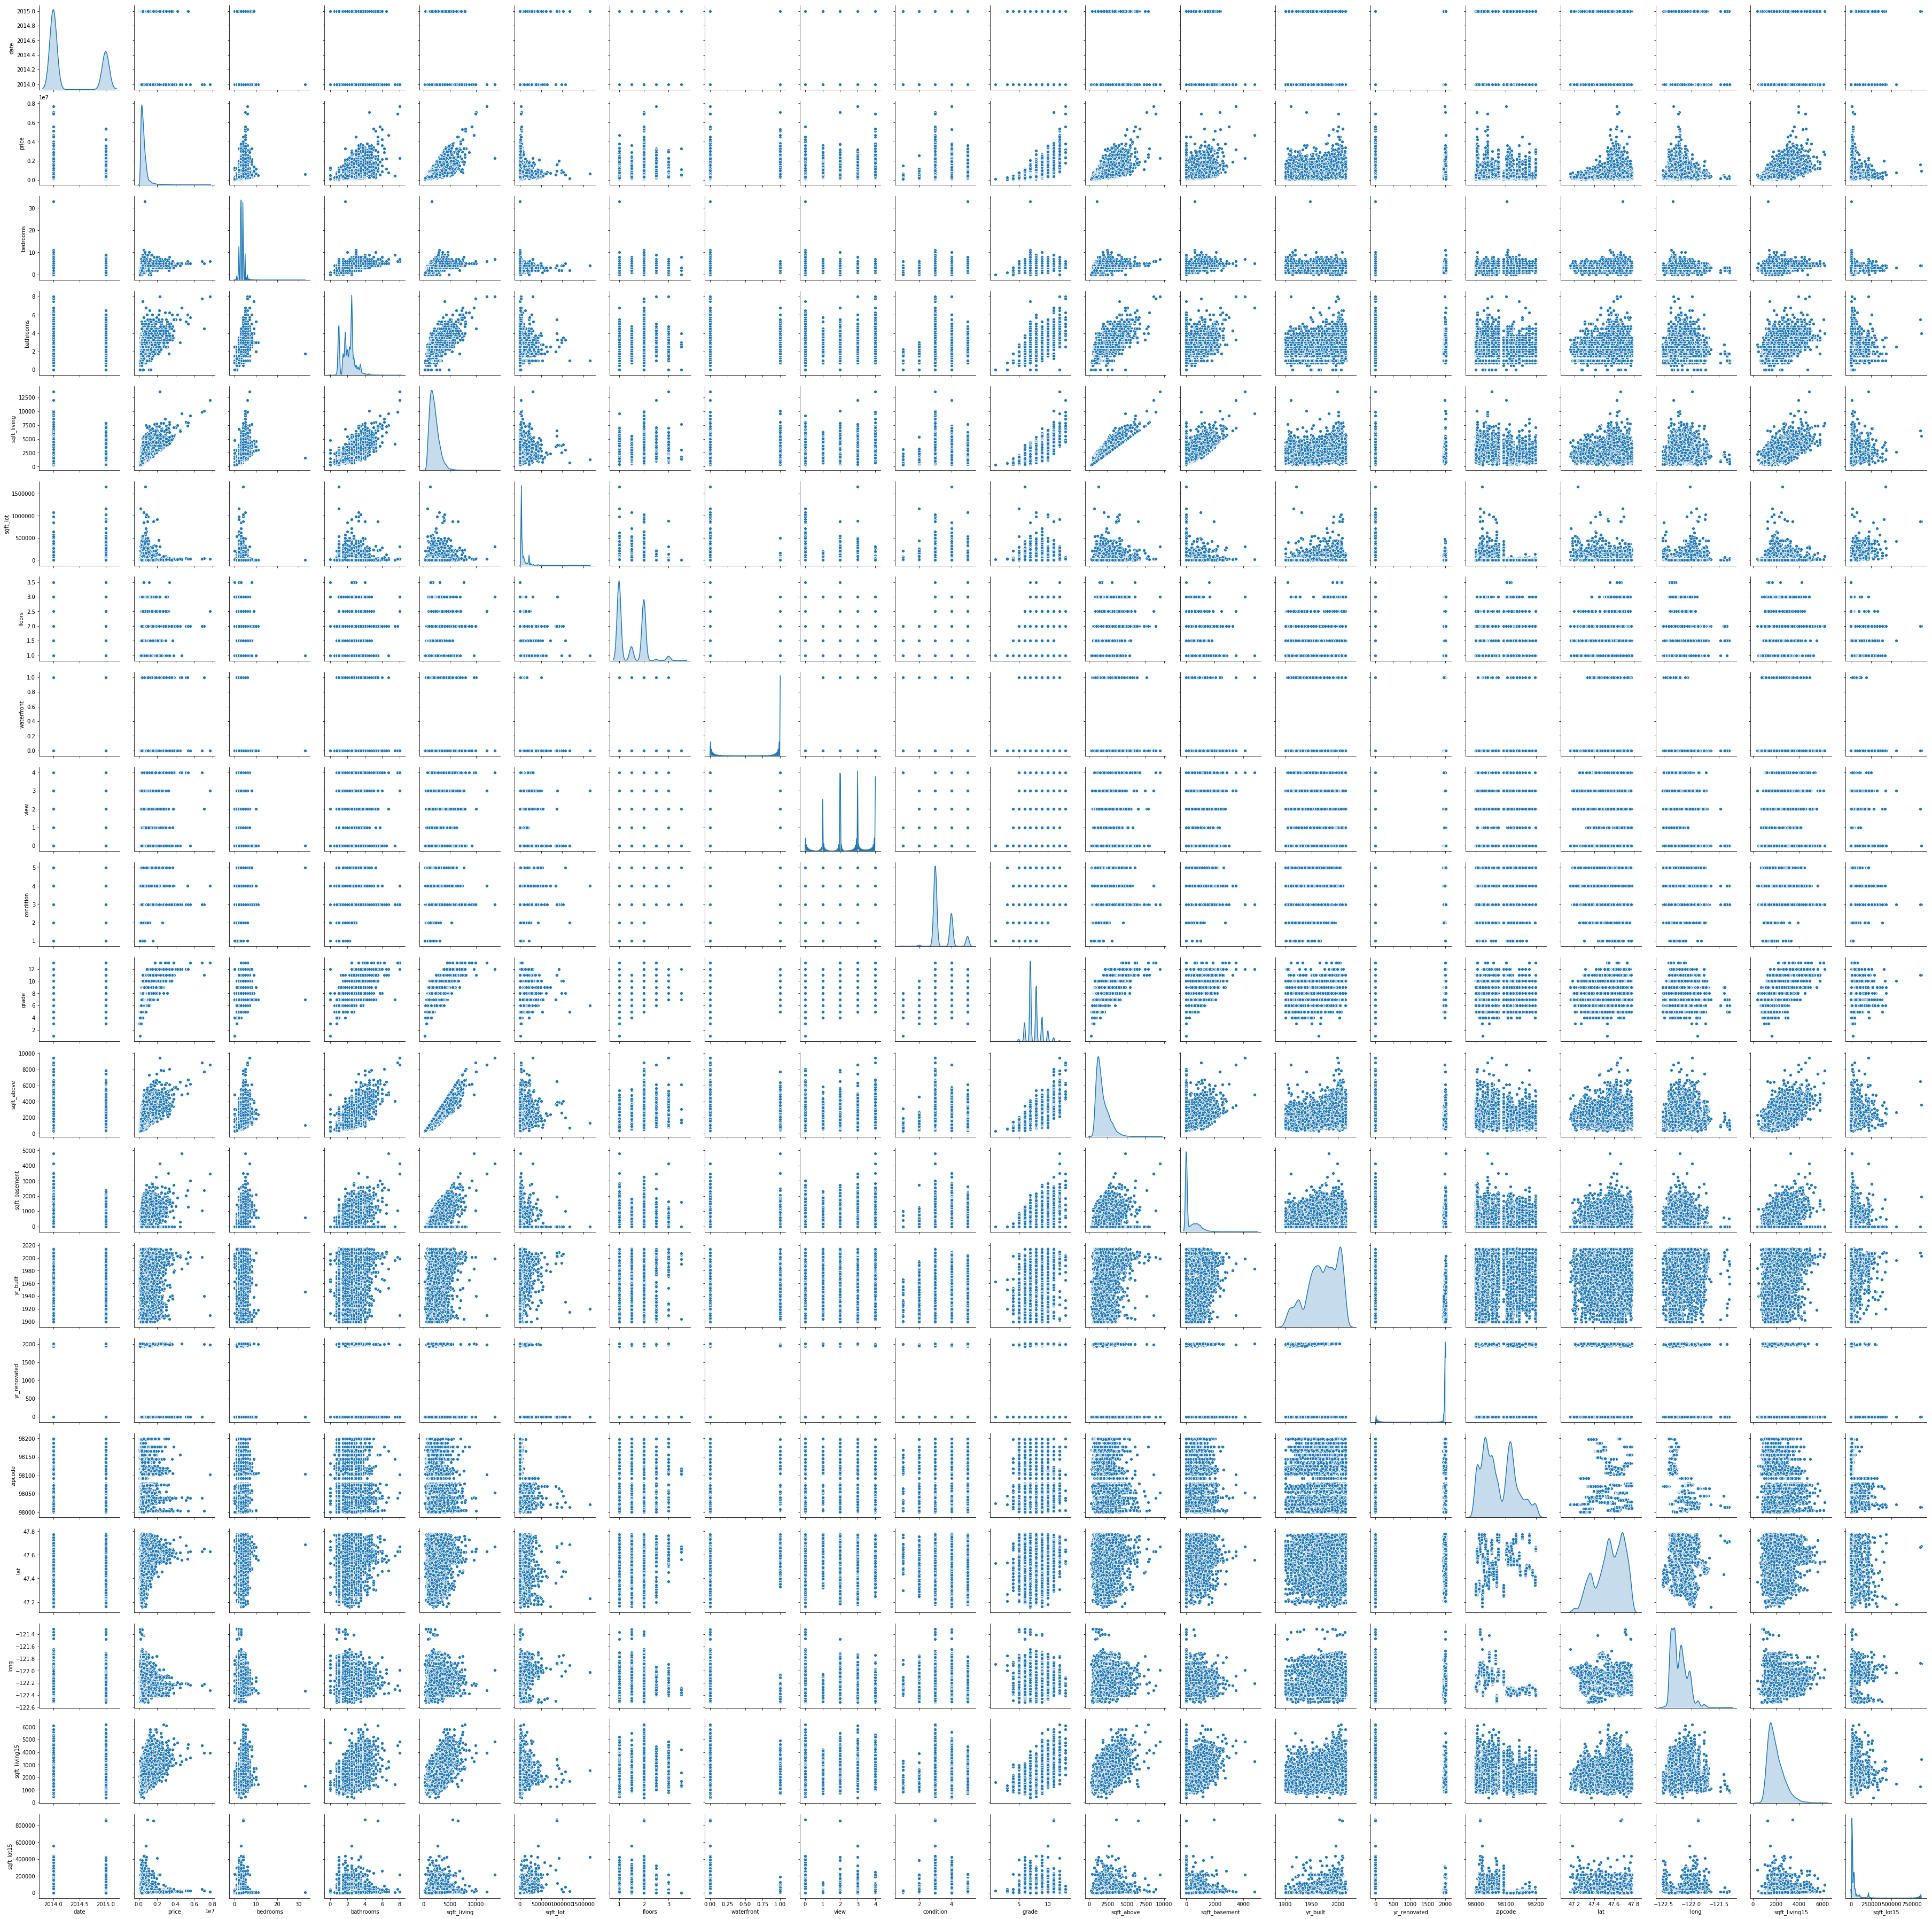

In [231]:
# Pairplot using sns
sns.pairplot(df,diag_kind="kde")

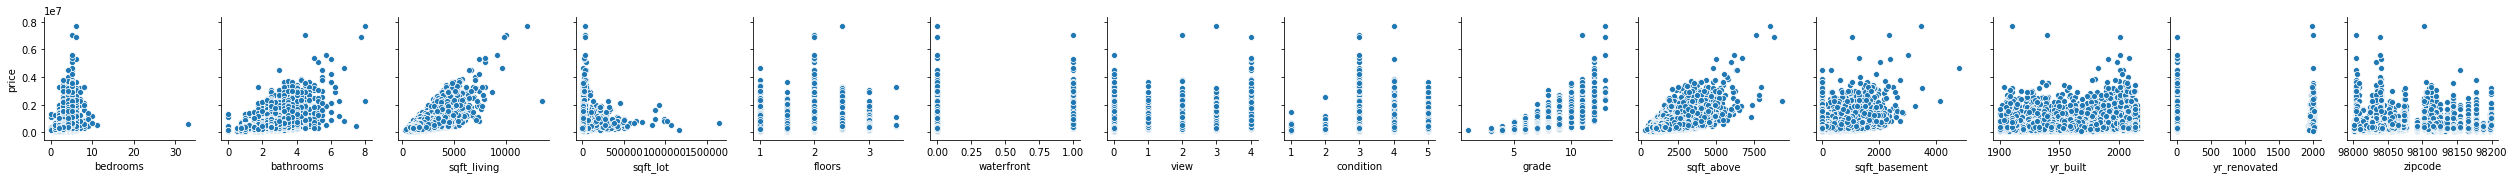

In [232]:
# check spread of feature cols wrt price
sns.pairplot(df, y_vars="price", x_vars=feature_cols)

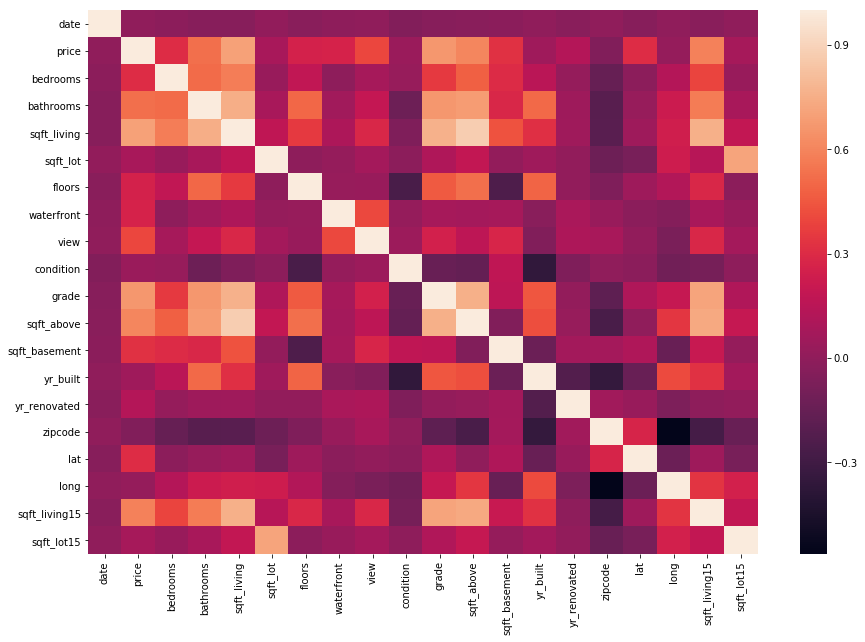

In [233]:
## Correlation HeatMap
plt.subplots(figsize = (15, 10))
sns.heatmap(df.corr())

In [234]:
# check co-relation of features wrt sqft_living
df[df.columns[2:]].corr()['sqft_living'][:].sort_values(ascending=False)

sqft_living      1.000000
sqft_above       0.876597
grade            0.762704
sqft_living15    0.756420
bathrooms        0.754665
bedrooms         0.576671
sqft_basement    0.435043
floors           0.353949
yr_built         0.318049
view             0.284611
long             0.240223
sqft_lot15       0.183286
sqft_lot         0.172826
waterfront       0.103818
yr_renovated     0.055363
lat              0.052529
condition       -0.058753
zipcode         -0.199430
Name: sqft_living, dtype: float64

98103    602
98038    590
98115    583
98052    574
98117    553
98042    548
98034    545
98118    508
98023    499
98006    498
98133    494
98059    468
98058    455
98155    446
98074    441
98033    432
98027    412
98125    410
98056    406
98053    405
98001    362
98075    359
98126    354
98092    351
98144    343
98106    335
98116    330
98029    321
98004    317
98199    317
        ... 
98168    269
98112    269
98055    268
98107    266
98136    263
98178    262
98030    256
98177    255
98166    254
98022    234
98105    229
98045    221
98002    199
98077    198
98011    195
98019    190
98108    186
98119    184
98005    168
98007    141
98188    136
98032    125
98014    124
98070    118
98109    109
98102    105
98010    100
98024     81
98148     57
98039     50
Name: zipcode, Length: 70, dtype: int64

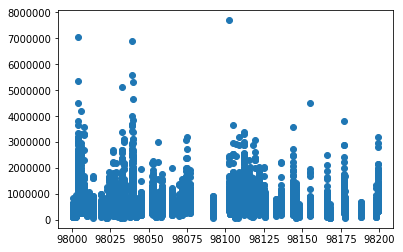

In [302]:
# Check spread of house price wrt zipcode
plt.scatter(df.zipcode,df.price)

In [235]:
# Insights :

# - The data set contains 21613 observations (home sales in 2014-15) with 19 features plus house price.
# - Price variable has the highest co-relation with sqft_living  with a corelation > 0.7    
# - The  pricing data is spread from $75K to $7.7million with living space from 290sqft to 13540sqft, which is a wide range
# - There is high co-relation between features - sqft_living has a strong liner co-relation between grade, sqft_above,sqft_living15 and bathrooms
# - There is no direct inference about the price of houses spread across the different zipcodes
# - PreProcessing of data might be needed to remove co-relations between features
# - The needs to have standardization to compensate for the wdiespread values aross different features

In [236]:
# Prepare X and Y
X = df.drop("price", axis=1)
y = df["price"] 

# Split the data into training and test set in the ratio of 70:30 respectively 
X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size = 0.30,random_state =2)

In [237]:
# Create Linear Regression Model
reg = LinearRegression()

# fit model in Training Data
reg.fit(X_train,y_train)
# check score in Test Data
reg_score = reg.score(X_test,y_test)
y_predict = reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_predict, y_test))
n_rmse = (np.sqrt(mse)/np.mean(Ytest)) * 100

print("Score from Base Linear Regression Model is ", reg_score)
print("Normalized RMSE from Base Linear Regression Model is ", n_rmse)

Score from Base Linear Regression Model is  0.7087397342278461
Normalized RMSE from Base Linear Regression Model is  25.34207121280639


In [238]:
# Find out important features or create new features to improve the performance for model

In [239]:
# Find out important features using Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

DT_model = DecisionTreeRegressor(criterion='mae',random_state=7)
DT_model.fit(X_train, y_train)
print (pd.Series(DT_model.feature_importances_, index = X_train.columns).sort_values(ascending=False))


lat              0.244149
grade            0.195236
sqft_living      0.167691
long             0.084342
sqft_living15    0.048270
yr_built         0.041196
sqft_lot         0.039465
sqft_above       0.035323
sqft_lot15       0.031821
zipcode          0.023794
bathrooms        0.017144
view             0.016346
sqft_basement    0.012095
waterfront       0.010025
condition        0.008813
bedrooms         0.007387
date             0.006891
floors           0.006438
yr_renovated     0.003574
dtype: float64


In [240]:
X = df.drop("price", axis=1)

# create new features to improve the performance for model
X['sales_yr'] = X['date']
# Indicate whether there is a basement or not
X['basement_present'] = X['sqft_basement'].apply(lambda X: 1 if X > 0 else 0) 
# Check if renovated instead of Renovated Year
X['renovated'] = X['yr_renovated'].apply(lambda X: 1 if X > 0 else 0)
# Calculate Age of House instead of Year directly
X['HouseAge'] =  X['sales_yr'].astype(int) - X['yr_built']
# Check renovation Age
X['age_rnv']=0
X['age_rnv']=X['sales_yr'][X['yr_renovated']!=0].astype(int)-X['yr_renovated'][X['yr_renovated']!=0]
X['age_rnv'][X['age_rnv'].isnull()]=0

X.shape

(21613, 24)

In [264]:
# Standardize the Data
sc = StandardScaler()
X_std =  sc.fit_transform(X)

X_std.shape

In [265]:
# can use PCA to remove co-relation and check if the Accuracy and RMSE scores are improved
from sklearn.decomposition import PCA

pca = PCA(n_components=24)
pca.fit(X_std)

# transform based on the principal components
X_pca = pca.transform(X_std)
X_pca.shape

(21613, 24)

In [266]:
# 6.	Use  cross validations techniques to find out the best predictor parameters and best prediction

In [267]:
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

LR = LinearRegression()

# Bagged & Boosted with LR as Base estimator 
bag_LR=BaggingRegressor(base_estimator=LR,n_estimators=51,random_state=0)
boost_LR=AdaBoostRegressor(base_estimator=LR,n_estimators = 51,random_state=0)

# Base estimator is Decision Tree as regressor
bag_DT=BaggingRegressor(n_estimators=51,random_state=0)
boost_DT=AdaBoostRegressor(n_estimators=51,random_state=0)

boost_G =GradientBoostingRegressor(n_estimators=51,random_state=0)

In [283]:
from sklearn.model_selection import KFold
from sklearn import metrics
kf=KFold(n_splits=5,shuffle=True,random_state=2)
for model, name in zip([LR,bag_LR,boost_LR,bag_DT,boost_DT,boost_G],
        ['LinearReg','BaggedLR','BoostedLR','BaggedDT','BoostedDT','GradientBoost']):
    rmse=[]
    for train,test in kf.split(X_std,y):
        Xtrain,Xtest=X_std[train,:],X_std[test,:]
        Ytrain,Ytest=y[train],y[test]
        model.fit(Xtrain,Ytrain)
        reg_score = model.score(Xtest,Ytest)
        Y_predict=model.predict(Xtest)
        mse=metrics.mean_squared_error(Ytest,Y_predict)
        n_rmse = (np.sqrt(mse)/np.mean(Ytest)) * 100
        rmse.append(n_rmse)
    print("Accuracy score : %0.04f, Normalized RMSE : %0.02f [%s]" % (reg_score, n_rmse, name ))   
    

Accuracy score : 0.7137, Normalized RMSE : 35.47 [LinearReg]
Accuracy score : 0.7136, Normalized RMSE : 35.47 [BaggedLR]
Accuracy score : 0.3930, Normalized RMSE : 51.64 [BoostedLR]
Accuracy score : 0.8877, Normalized RMSE : 22.22 [BaggedDT]
Accuracy score : 0.2185, Normalized RMSE : 58.60 [BoostedDT]
Accuracy score : 0.8538, Normalized RMSE : 25.34 [GradientBoost]


In [246]:
# Based on the above observations, the best model could be a Bagged Decision Tree or a Gradent Boost Regressor Model
# Use GridSearchCV to fine tune hyper parameters and identify the best performing model

In [295]:
# Perform Grid Search Method to find the optimal parameters for Decision Tree Regressor
model = bag_DT

bag_DT.get_params().keys()

param_grid = {
        'n_estimators': [100,300],
        'max_features': [5,15],
      }

GS=GridSearchCV(model,param_grid,cv=3)

GS.fit(Xtrain,Ytrain)
print(GS.best_params_)

gs_pred=GS.predict(Xtest)
mse=metrics.mean_squared_error(Ytest,gs_pred)
n_rmse = (np.sqrt(mse)/np.mean(Ytest)) * 100

reg_score = GS.score(Xtest,Ytest)
print("Accuracy with Optimal Grid Search Parameters for Bagged DT Model is {}".format(reg_score*100))
print("Normalized RMSE score is {}".format(n_rmse))

{'max_features': 15, 'n_estimators': 100}
Accuracy with Optimal Grid Search Parameters for Bagged DT Model is 88.98312524695952
Normalized RMSE score is 22.00155661335258


In [296]:
# Perform Grid Search Method to find the optimal parameters for Gradient Boost Regressor
model = boost_G

boost_G.get_params().keys()
param_grid = {
        'n_estimators': [100,300],
        'max_depth': [3,5],
        'min_samples_split': [2,3]
      }

GS=GridSearchCV(model,param_grid,cv=3)

GS.fit(Xtrain,Ytrain)
print(GS.best_params_)

gs_pred=GS.predict(Xtest)
mse=metrics.mean_squared_error(Ytest,gs_pred)
n_rmse = (np.sqrt(mse)/np.mean(Ytest)) * 100

reg_score = GS.score(Xtest,Ytest)
print("Accuracy with Optimal Grid Search Parameters for Gradient Boost Model is {}% .".format(reg_score*100))
print("Normalized RMSE score is {}".format(n_rmse))

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy with Optimal Grid Search Parameters for Gradient Boost Model is 90.74701039435095% .
Normalized RMSE score is 20.163468420611373


In [ ]:
# Based on the above observations Gradient Boost Regressor Model seems to be giving the best prediction.
# After tuning of parameters, the model gives an accuracy of 90.74%  and Normalized RMSE of 20.16